In [72]:
import pandas as pd

In [73]:
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep = ";")
red["wine_type"] = 0
white["wine_type"] = 1

df = pd.concat([red, white], ignore_index=True)
df = df.drop_duplicates(ignore_index=True)


<bound method NDFrame.head of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
4               7.4              0.66         0.00             1.8      0.075   
...             ...               ...          ...             ...        ...   
5315            6.2              0.21         0.29             1.6      0.039   
5316            6.6              0.32         0.36             8.0      0.047   
5317            6.5              0.24         0.19             1.2      0.041   
5318            5.5              0.29         0.30             1.1      0.022   
5319            6.0              0.21         0.38             0.8      0.020  

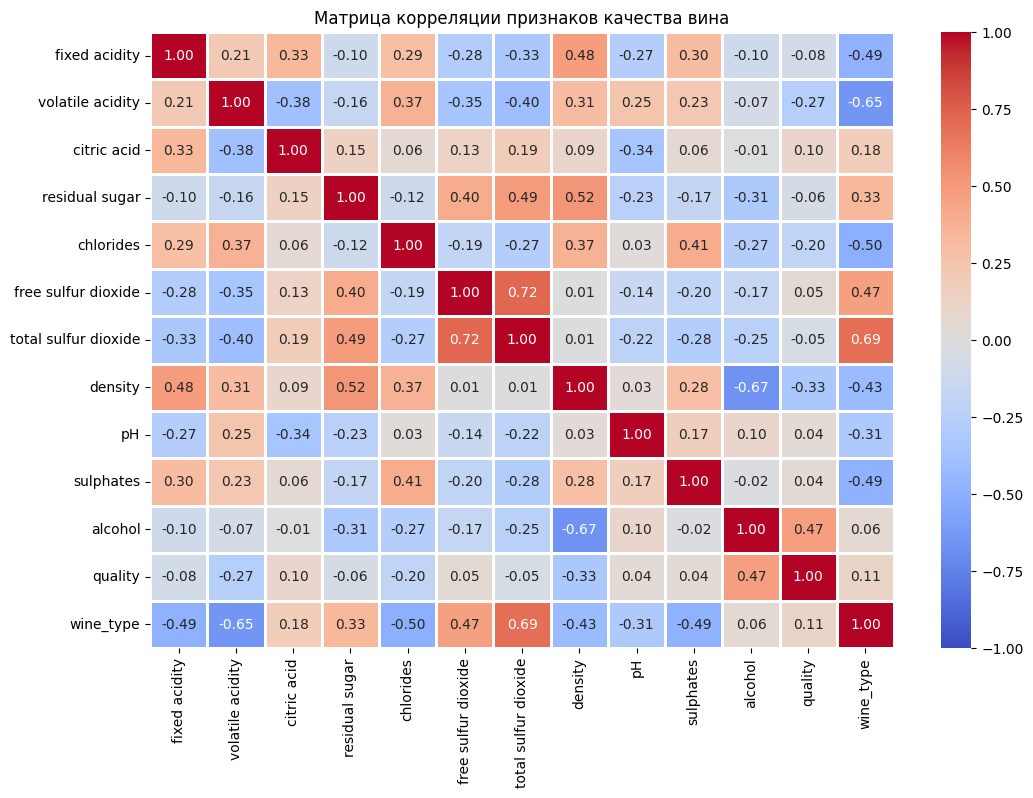

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.head)
print(df.describe())
print(df["quality"].value_counts().sort_index())
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))

sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt=".2f", linewidths=1.0)

plt.title("Матрица корреляции признаков качества вина")
plt.show()

In [75]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="quality")
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(4256, 12) (1064, 12)


In [76]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

predicted_baseline = baseline.predict(X_test)


In [77]:
results = {}

def evaluate(name, y_true, y_predicted):
    results[name] = {
        "RMSE": root_mean_squared_error(y_true, y_predicted),
        "MAE": mean_absolute_error(y_true, y_predicted)
    }
    
    print(f"{name}: RMSE = {results[name]['RMSE']:.5f}, MAE = {results[name]['MAE']:.5f}")
    
evaluate("Baseline", y_test, predicted_baseline,)

Baseline: RMSE = 0.88010, MAE = 0.69479


In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

linear_model = make_pipeline(StandardScaler(), LinearRegression())

linear_model.fit(X_train, y_train)
linear_model_predicted = linear_model.predict(X_test)
evaluate("LinearRegression: ", y_test, linear_model_predicted)

LinearRegression: : RMSE = 0.72924, MAE = 0.56600


In [96]:
import numpy as np
from sklearn.linear_model import Ridge

ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1)
)

ridge_model.fit(X_train, y_train)
ridge_model_predicted = ridge_model.predict(X_test)

evaluate("Ridge", y_test, ridge_model_predicted)

Ridge: RMSE = 0.72925, MAE = 0.56601


In [110]:
import numpy as np
from sklearn.linear_model import Lasso

lasso_model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.0001)
)

lasso_model.fit(X_train, y_train)
lasso_model_predicted = lasso_model.predict(X_test)

evaluate("Ridge", y_test, lasso_model_predicted)

Ridge: RMSE = 0.72926, MAE = 0.56601
